# Hybryda LSTM + XGBoost — prognoza ceny BTC na horyzoncie +7 dni (168h)

**Dlaczego ten horyzont:** praca *"Forecasting Bitcoin price direction with random forests"*
(ScienceDirect) pokazała, że trafność kierunkowa systematycznie rośnie z horyzontem —
75-80% dla prognozy 5-dniowej, >85% dla 10-20 dni — na **makroekonomicznych** zmiennych
(stopy procentowe, inflacja, VIX, ropa), których jeszcze nie mamy. Zanim dodamy nowe źródła
danych, sprawdzamy najpierw, czy sam dłuższy horyzont (+7 dni zamiast +1h/+24h) poprawia
stosunek sygnał/szum **na już posiadanych cechach** (whale, opcje, wskaźniki techniczne).

## Dwie poprawki wbudowane od razu (na bazie wniosków z +1h i +24h)

**1. Wycentrowanie dryfu.** Przy +24h zobaczyliśmy: dryf treningowy (+0.00115) ≠ dryf testowy
(-0.00030) — model uczył się głównie kierunku rynku z okresu treningowego, nie realnej
zależności od cech. Przy +7 dniach ten efekt będzie jeszcze silniejszy (dłuższy horyzont =
większa kumulacja trendu), więc **od razu** odejmujemy kroczącą 30-dniową średnią zwrotu
przed treningiem.

**2. Zbalansowana architektura.** `LayerNormalization` prowadziła do mode collapse (model
zawsze przewidywał "wzrost", odch. std. predykcji ≈0.00006). Brak normalizacji prowadził do
natychmiastowego przeuczenia. Tu: mniejszy model (`LSTM(16)`) + `recurrent_dropout` +
`kernel_regularizer(l2)` + `clipnorm` — łagodniejsza regularizacja bez całkowitego tłumienia
wariancji predykcji.

## 1. Importy i konfiguracja

In [131]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import warnings, io, re
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import xgboost as xgb

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

COLOR_TRUE = '#111111'
COLOR_LSTM = '#1565C0'
COLOR_HYBRID = '#C62828'
COLOR_NAIVE = '#9E9E9E'

OUT_DIR = './data/hourly/processed'
os.makedirs(OUT_DIR, exist_ok=True)

print('Biblioteki wczytane pomyślnie.')
print(f'TensorFlow: {tf.__version__}   XGBoost: {xgb.__version__}')

Biblioteki wczytane pomyślnie.
TensorFlow: 2.16.2   XGBoost: 3.2.0


## 2. Wczytanie danych i cel: zwrot za 7 dni, wycentrowany

**Cel: `target_return_7d_fwd_detrended`** = `ln(Close[t+168]/Close[t])` **minus** krocząca
30-dniowa średnia tego zwrotu (licząc wyłącznie z przeszłości, `shift(1)` żeby nie zaglądać
w przyszłość).

In [132]:
HORIZON = 72        # 7 dni w godzinach
DRIFT_WINDOW = 360   # 30 dni w godzinach, do wyliczenia dryfu

CSV_PATH = '/Users/mateuszpuk/Desktop/bitcoin-onchain-analysis/src/hourly/data/hourly/processed/bitcoin_hourly_final.csv'   # <- Twoja ścieżka

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').set_index('timestamp')
df = df.interpolate(method='linear', limit_direction='forward').ffill().dropna()

# 1. Rzeczywisty zwrot w przód (+7 dni) — etykieta celu do predykcji
df['target_return_7d_fwd'] = np.log(df['Close'].shift(-HORIZON) / df['Close'])

# 2. Zwrot 7-dniowy WSTECZ (w 100% znany w chwili t)
df['past_return_7d'] = np.log(df['Close'] / df['Close'].shift(HORIZON))

# 3. Średnia krocząca liczona wyłącznie z przeszłości (brak wycieku danych)
df['rolling_drift'] = df['past_return_7d'].rolling(DRIFT_WINDOW, min_periods=HORIZON).mean()

# 4. Wycentrowany cel (target do treningu)
df['target_return_7d_detrended'] = df['target_return_7d_fwd'] - df['rolling_drift']

# Usunięcie wierszy z brakującymi wartościami
df = df.dropna(subset=['target_return_7d_fwd', 'past_return_7d', 'rolling_drift', 'target_return_7d_detrended'])

print(f'Zakres dat:      {df.index.min()} → {df.index.max()}')
print(f'Liczba rekordów: {len(df):,}')
print(df[['target_return_7d_fwd', 'rolling_drift', 'target_return_7d_detrended']].describe())

Zakres dat:      2022-05-15 23:00:00 → 2026-08-14 20:00:00
Liczba rekordów: 35,711
       target_return_7d_fwd  rolling_drift  target_return_7d_detrended
count          35711.000000   35711.000000                35711.000000
mean               0.001507       0.001516                   -0.000009
std                0.045268       0.020039                    0.049009
min               -0.336885      -0.083783                   -0.340578
25%               -0.020798      -0.008132                   -0.028015
50%                0.001099       0.000907                   -0.000779
75%                0.024424       0.011934                    0.026589
max                0.255211       0.062751                    0.285352


## 3. Cechy wejściowe (ten sam zestaw co poprzednio)

In [133]:
# 1. Inżynieria cech względnych (zabezpieczenie przed niestacjonarnością)
df['dist_sma_168h'] = (df['Close'] - df['sma_168h']) / df['sma_168h']
df['trend_alignment_168_720'] = (df['sma_168h'] - df['sma_720h']) / df['sma_720h']

# 2. Nowy zestaw cech do modelu (Etap 1 i 2)
FEATURE_COLS = [
    # A. Dynamika ceny i oscylatory (Krótki horyzont)
    'log_return_1h',
    'log_return_24h',
    'rsi_14h',
    'macd_hist',
    'bollinger_bandwidth',
    
    # B. Długoterminowy reżim trendu (Chroni przed shortowaniem hossy)
    'dist_sma_168h',
    'trend_alignment_168_720',
    
    # C. Rynek opcji i sentyment instytucjonalny (Kluczowe)
    'delta_call_bias_30d',
    'delta_call_momentum_24h',
    'dvol_zscore_168h',
    'price_above_options_upper',
    
    # D. Aktywność wielorybów i płynność (Z-Score)
    'whale_tx_count_zscore_168h',
    'volume_usdt_zscore_168h',
    'stablecoin_vol_momentum_24h',
    'active_addresses'
]

# Filtracja kolumn istniejących w DataFrame
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Wybrano {len(FEATURE_COLS)} zaawansowanych cech wejściowych.')
TARGET_COL = 'target_return_7d_detrended'

print(f'Liczba cech wejściowych: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Wybrano 15 zaawansowanych cech wejściowych.
Liczba cech wejściowych: 15
['log_return_1h', 'log_return_24h', 'rsi_14h', 'macd_hist', 'bollinger_bandwidth', 'dist_sma_168h', 'trend_alignment_168_720', 'delta_call_bias_30d', 'delta_call_momentum_24h', 'dvol_zscore_168h', 'price_above_options_upper', 'whale_tx_count_zscore_168h', 'volume_usdt_zscore_168h', 'stablecoin_vol_momentum_24h', 'active_addresses']


## 4. Podział chronologiczny (80/10/10)

In [134]:
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

n = len(df)
n_train = int(n * TRAIN_FRAC)
n_val   = int(n * VAL_FRAC)

train_df = df.iloc[:n_train - HORIZON]
val_df   = df.iloc[n_train : n_train + n_val - HORIZON]
test_df  = df.iloc[n_train + n_val :]

print(f'Trening:    {len(train_df):>7,} godzin   ({train_df.index.min()} → {train_df.index.max()})')
print(f'Walidacja:  {len(val_df):>7,} godzin   ({val_df.index.min()} → {val_df.index.max()})')
print(f'Test:       {len(test_df):>7,} godzin   ({test_df.index.min()} → {test_df.index.max()})')

print()
print(f'Średni zwrot 7d w treningu (przed wycentrowaniem): {train_df["target_return_7d_fwd"].mean():.5f}')
print(f'Średni zwrot 7d w teście   (przed wycentrowaniem): {test_df["target_return_7d_fwd"].mean():.5f}')
print(f'Średni zwrot 7d w treningu (PO wycentrowaniu):     {train_df[TARGET_COL].mean():.5f}')
print(f'Średni zwrot 7d w teście   (PO wycentrowaniu):     {test_df[TARGET_COL].mean():.5f}')

Trening:     28,496 godzin   (2022-05-15 23:00:00 → 2025-09-07 04:00:00)
Walidacja:    3,499 godzin   (2025-09-10 08:00:00 → 2026-02-12 10:00:00)
Test:         3,572 godzin   (2026-02-15 14:00:00 → 2026-08-14 20:00:00)

Średni zwrot 7d w treningu (przed wycentrowaniem): 0.00332
Średni zwrot 7d w teście   (przed wycentrowaniem): -0.00149
Średni zwrot 7d w treningu (PO wycentrowaniu):     0.00002
Średni zwrot 7d w teście   (PO wycentrowaniu):     0.00115


## 5. Skalowanie i sekwencje

Okno wejściowe: 24h historii (jak w poprzednich notebookach) → prognoza wycentrowanego zwrotu
za kolejne 7 dni.

In [135]:
WINDOW_LSTM = 72

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = scaler_X.fit_transform(train_df[FEATURE_COLS].values)
X_val_raw   = scaler_X.transform(val_df[FEATURE_COLS].values)
X_test_raw  = scaler_X.transform(test_df[FEATURE_COLS].values)

y_train_raw = scaler_y.fit_transform(train_df[[TARGET_COL]].values)
y_val_raw   = scaler_y.transform(val_df[[TARGET_COL]].values)
y_test_raw  = scaler_y.transform(test_df[[TARGET_COL]].values)

def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i, :])
        ys.append(y[i, 0])
    return np.array(Xs), np.array(ys)

X_tr, y_tr = make_sequences(X_train_raw, y_train_raw, WINDOW_LSTM)
X_va, y_va = make_sequences(X_val_raw,   y_val_raw,   WINDOW_LSTM)
X_te, y_te = make_sequences(X_test_raw,  y_test_raw,  WINDOW_LSTM)

n_features = X_tr.shape[-1]
print(f'Sekwencje: train={X_tr.shape}  val={X_va.shape}  test={X_te.shape}')

# Prawdziwe (nieskalowane, WYCENTROWANE) zwroty
train_return_detrended_true = train_df[TARGET_COL].values[WINDOW_LSTM:]
val_return_detrended_true   = val_df[TARGET_COL].values[WINDOW_LSTM:]
test_return_detrended_true  = test_df[TARGET_COL].values[WINDOW_LSTM:]

# Dryf odpowiadający tym samym wierszom (do odtworzenia pełnego zwrotu i ceny)
train_drift = train_df['rolling_drift'].values[WINDOW_LSTM:]
val_drift   = val_df['rolling_drift'].values[WINDOW_LSTM:]
test_drift  = test_df['rolling_drift'].values[WINDOW_LSTM:]

train_last_close = train_df['Close'].values[WINDOW_LSTM:]
val_last_close   = val_df['Close'].values[WINDOW_LSTM:]
test_last_close  = test_df['Close'].values[WINDOW_LSTM:]

test_return_full_true = test_df['target_return_7d_fwd'].values[WINDOW_LSTM:]  # pełny (niewycentrowany) zwrot
test_price_true = test_last_close * np.exp(test_return_full_true)

Sekwencje: train=(28424, 72, 15)  val=(3427, 72, 15)  test=(3500, 72, 15)


## 6. Etap 1 — LSTM (mniejszy model, łagodniejsza regularizacja)

`LSTM(16)` (znacznie mniejszy niż `K_HIDDEN=64` z artykułu — przy tak słabym sygnale duża
pojemność szkodzi bardziej niż pomaga, jak widzieliśmy przy +24h) z `recurrent_dropout`,
`kernel_regularizer(l2)` i `clipnorm` (przeciw dużym gradientom od nietypowych ruchów cen).

In [136]:
import io
import re
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def print_polish_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    s = stream.getvalue()
    names = {'dense': 'Gęsta', 'dropout': 'Dropout', 'lstm': 'LSTM', 
             'inputlayer': 'Wejście', 'layernormalization': 'Normalizacja warstw'}
    def shorten(m):
        t = m.group(2).lower()
        return f'{names.get(t, m.group(2)):<{len(m.group(0))}}'
    s = re.sub(r'(\w+)\s*\((\w+)\)', shorten, s)
    for eng, pol in {
        "type         ": "Warstwa (typ)", "Output Shape   ": "Kształt wyjścia",
        "  Param #": "Parametry", "Total params:": "Suma parametrów:        ",
        "Trainable params:": "Parametry trenowalne:   ",
        "Non-trainable params:": "Parametry nietrenowalne:",
    }.items():
        s = s.replace(eng, pol)
    print(s)

K_HIDDEN = 16

# 1. Architektura zoptymalizowana pod ekstrakcję cech (Etap 1)
inputs = Input(shape=(WINDOW_LSTM, n_features), name='input_layer')

lstm_out = LSTM(
    K_HIDDEN,
    kernel_regularizer=l2(0.0005),
    name='lstm_feature_extractor',
)(inputs)

# Stabilizacja wektora ukrytego przed przekazaniem do Dense / XGBoost
norm = LayerNormalization()(lstm_out)
drop = Dropout(0.2)(norm)

return_head = Dense(1, kernel_regularizer=l2(0.0005), name='return_head')(drop)

lstm_model = Model(inputs=inputs, outputs=return_head)
feature_extractor = Model(inputs=inputs, outputs=lstm_out)

# 2. Huber Loss (odporny na skoki krypto) + niższy Learning Rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, clipnorm=0.5)
lstm_model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=1.0))

print_polish_summary(lstm_model)

cb = [
    EarlyStopping(
        monitor='val_loss', 
        patience=20, 
        restore_best_weights=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=6, 
        min_lr=1e-6, 
        verbose=1
    ),
]

print('Trening LSTM (Etap 1)...')
hist = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=120,
    batch_size=256,   # <-- Większy batch uśrednia szum rynkowy (zamiast 64)
    callbacks=cb,
    verbose=1,
    shuffle=True,
)
print('✓ LSTM wytrenowany.')

Model: "functional_16"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Warstwa (typ)                   ┃ Kształt wyjścia        ┃     Parametry ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Wejście                         │ (None, 72, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM                            │ (None, 16)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 16)             │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout                         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gęsta                           │ (None, 1)        

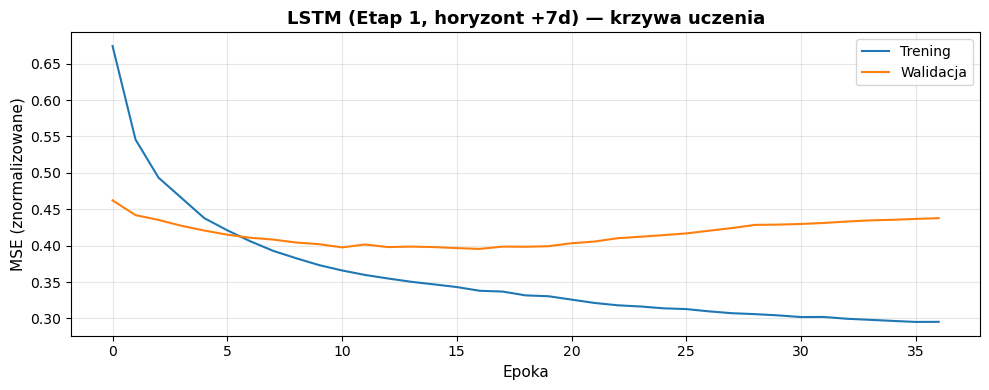

In [137]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist.history['loss'], label='Trening')
ax.plot(hist.history['val_loss'], label='Walidacja')
ax.set_title('LSTM (Etap 1, horyzont +7d) — krzywa uczenia', fontweight='bold')
ax.set_xlabel('Epoka')
ax.set_ylabel('MSE (znormalizowane)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hybrid7d_lstm_learning_curve.png'), bbox_inches='tight', dpi=130)
plt.show()

## 7. Ekstrakcja wektora `z`

In [138]:
z_train = feature_extractor.predict(X_tr, verbose=0)
z_val   = feature_extractor.predict(X_va, verbose=0)
z_test  = feature_extractor.predict(X_te, verbose=0)

print(f'Wektory cech (z): train={z_train.shape}  val={z_val.shape}  test={z_test.shape}')

Wektory cech (z): train=(28424, 16)  val=(3427, 16)  test=(3500, 16)


## 8. Etap 2 — XGBoost (prognoza wycentrowanego zwrotu)

In [139]:
z_train_aug = np.ascontiguousarray(np.hstack([z_train, train_last_close.reshape(-1, 1)]), dtype=np.float32)
z_val_aug   = np.ascontiguousarray(np.hstack([z_val,   val_last_close.reshape(-1, 1)]),   dtype=np.float32)
z_test_aug  = np.ascontiguousarray(np.hstack([z_test,  test_last_close.reshape(-1, 1)]),  dtype=np.float32)

y_train_xgb = np.ascontiguousarray(train_return_detrended_true, dtype=np.float32)
y_val_xgb   = np.ascontiguousarray(val_return_detrended_true,   dtype=np.float32)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse',
    tree_method='hist',
    n_jobs=1,
)

print(f'Wymiary danych treningowych: {z_train_aug.shape}')
print('Trening XGBoost (Etap 2)...')
xgb_model.fit(z_train_aug, y_train_xgb, eval_set=[(z_val_aug, y_val_xgb)], verbose=50)
print(f'✓ XGBoost wytrenowany (najlepsza iteracja: {xgb_model.best_iteration}).')

Wymiary danych treningowych: (28424, 17)
Trening XGBoost (Etap 2)...
[0]	validation_0-rmse:0.04624
[42]	validation_0-rmse:0.04628
✓ XGBoost wytrenowany (najlepsza iteracja: 12).


## 9. Predykcje: rekonstrukcja pełnego zwrotu i ceny

Odtwarzamy pełny zwrot dodając z powrotem dryf: `zwrot_pełny = zwrot_wycentrowany + dryf`,
a cenę: `cena = Close[t] × exp(zwrot_pełny)`.

In [140]:
# 1. Naive persistence: zwrot = 0 (cena się nie zmienia)
pred_return_full_naive = np.zeros_like(test_return_full_true)

# 2. LSTM (Etap 1): przewiduje ZWROT WYCENTROWANY, dodajemy dryf z powrotem
pred_detrended_lstm_scaled = lstm_model.predict(X_te, verbose=0)
pred_detrended_lstm = scaler_y.inverse_transform(pred_detrended_lstm_scaled).flatten()
pred_return_full_lstm = pred_detrended_lstm + test_drift

# 3. Hybryda LSTM+XGBoost (Etap 2): też przewiduje zwrot wycentrowany
pred_detrended_hybrid = xgb_model.predict(z_test_aug)
pred_return_full_hybrid = pred_detrended_hybrid + test_drift

# Rekonstrukcja cen
pred_price_naive  = test_last_close * np.exp(pred_return_full_naive)
pred_price_lstm   = test_last_close * np.exp(pred_return_full_lstm)
pred_price_hybrid = test_last_close * np.exp(pred_return_full_hybrid)

print('Przygotowano predykcje dla 3 wariantów (horyzont +7 dni).')
print(f'n_test = {len(test_return_full_true):,}')

Przygotowano predykcje dla 3 wariantów (horyzont +7 dni).
n_test = 3,500


## 10. Metryki: MAPE/MinMax RMSE (na cenie) + DA

DA liczona na **pełnym** (nie wycentrowanym) zwrocie — to jest wartość, która realnie
interesuje inwestora: czy cena poszła w górę czy w dół względem dziś.

In [141]:
def mape(y_true, y_pred):
    return 100.0 * np.mean(np.abs((y_true - y_pred) / y_true))

def minmax_rmse(y_true, y_pred, y_true_for_range):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / (y_true_for_range.max() - y_true_for_range.min())

def binary_direction(returns):
    return (returns > 0).astype(int)

true_dir = binary_direction(test_return_full_true)

def directional_accuracy(pred_returns):
    pred_dir = binary_direction(pred_returns)
    return float(np.mean(pred_dir == true_dir)) * 100

results = []
for name, pred_ret, pred_price in [
    ('Naive persistence', pred_return_full_naive, pred_price_naive),
    ('LSTM (Etap 1)', pred_return_full_lstm, pred_price_lstm),
    ('LSTM + XGBoost (hybryda)', pred_return_full_hybrid, pred_price_hybrid),
]:
    results.append({
        'Model': name,
        'MAPE ceny (%)': mape(test_price_true, pred_price),
        'MinMax RMSE (cena)': minmax_rmse(test_price_true, pred_price, test_price_true),
        'MAE zwrotu': mean_absolute_error(test_return_full_true, pred_ret),
        'DA (%)': directional_accuracy(pred_ret),
    })

results_df = pd.DataFrame(results)
print(f'Rozkład rzeczywistego kierunku w teście: wzrost={true_dir.mean():.1%}, spadek={1-true_dir.mean():.1%}')
print()
print(results_df.to_string(index=False, formatters={
    'MAPE ceny (%)': '{:.4f}'.format,
    'MinMax RMSE (cena)': '{:.5f}'.format,
    'MAE zwrotu': '{:.5f}'.format,
    'DA (%)': '{:.2f}'.format,
}))

Rozkład rzeczywistego kierunku w teście: wzrost=50.8%, spadek=49.2%

                   Model MAPE ceny (%) MinMax RMSE (cena) MAE zwrotu DA (%)
       Naive persistence        2.7812            0.10990    0.02757  49.17
           LSTM (Etap 1)        3.0263            0.11355    0.02989  48.57
LSTM + XGBoost (hybryda)        2.9575            0.11223    0.02942  47.51


## 10b. Diagnostyka: czy model faktycznie różnicuje predykcje?

In [142]:
for name, pred in [('LSTM', pred_return_full_lstm), ('Hybryda', pred_return_full_hybrid)]:
    pct_positive = (pred > 0).mean()
    print(f'{name}:')
    print(f'  % predykcji > 0 (wzrost):        {pct_positive:.1%}')
    print(f'  Średnia predykcja:                 {pred.mean():.5f}')
    print(f'  Odch. std. predykcji:              {pred.std():.5f}')
    print(f'  Odch. std. rzeczywistych zwrotów:  {test_return_full_true.std():.5f}')
    print()

n = len(test_return_full_true)
se = np.sqrt(0.5 * 0.5 / n)
print(f'Test istotności DA (n={n:,}, odch. std. losowego zgadywania = {se*100:.2f} p.p.):')
for name, da in zip(['Naive', 'LSTM', 'Hybryda'], results_df['DA (%)'].values):
    z_score = (da - 50) / (se * 100)
    print(f'  {name:10}: DA={da:.2f}%  ({z_score:+.2f} odch. std. od 50%)')

LSTM:
  % predykcji > 0 (wzrost):        64.0%
  Średnia predykcja:                 0.00583
  Odch. std. predykcji:              0.01353
  Odch. std. rzeczywistych zwrotów:  0.03868

Hybryda:
  % predykcji > 0 (wzrost):        57.9%
  Średnia predykcja:                 0.00000
  Odch. std. predykcji:              0.01421
  Odch. std. rzeczywistych zwrotów:  0.03868

Test istotności DA (n=3,500, odch. std. losowego zgadywania = 0.85 p.p.):
  Naive     : DA=49.17%  (-0.98 odch. std. od 50%)
  LSTM      : DA=48.57%  (-1.69 odch. std. od 50%)
  Hybryda   : DA=47.51%  (-2.94 odch. std. od 50%)


## 11. Wizualizacja

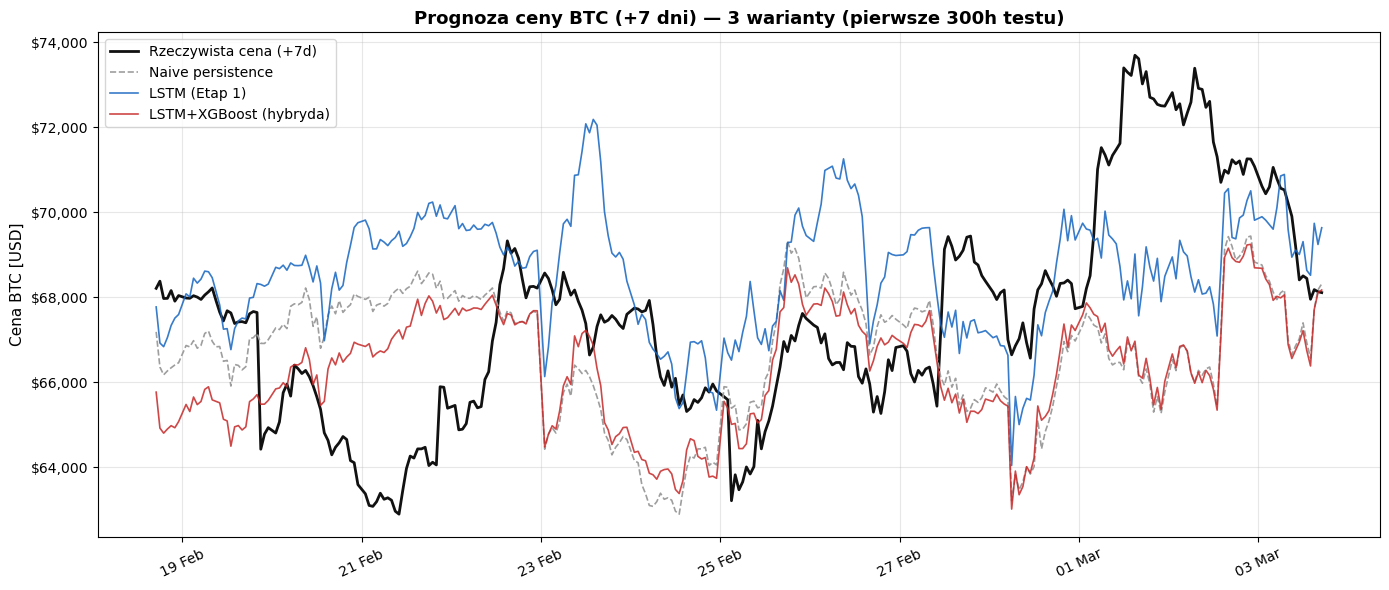

In [143]:
test_dates = test_df.index[WINDOW_LSTM:]
n_show = min(300, len(test_dates))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates[:n_show], test_price_true[:n_show], color=COLOR_TRUE, lw=2.0, label='Rzeczywista cena (+7d)')
ax.plot(test_dates[:n_show], pred_price_naive[:n_show], color=COLOR_NAIVE, lw=1.2, ls='--', label='Naive persistence')
ax.plot(test_dates[:n_show], pred_price_lstm[:n_show], color=COLOR_LSTM, lw=1.2, alpha=0.85, label='LSTM (Etap 1)')
ax.plot(test_dates[:n_show], pred_price_hybrid[:n_show], color=COLOR_HYBRID, lw=1.2, alpha=0.85, label='LSTM+XGBoost (hybryda)')
ax.set_title(f'Prognoza ceny BTC (+7 dni) — 3 warianty (pierwsze {n_show}h testu)', fontweight='bold')
ax.set_ylabel('Cena BTC [USD]')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hybrid7d_predictions.png'), bbox_inches='tight', dpi=130)
plt.show()

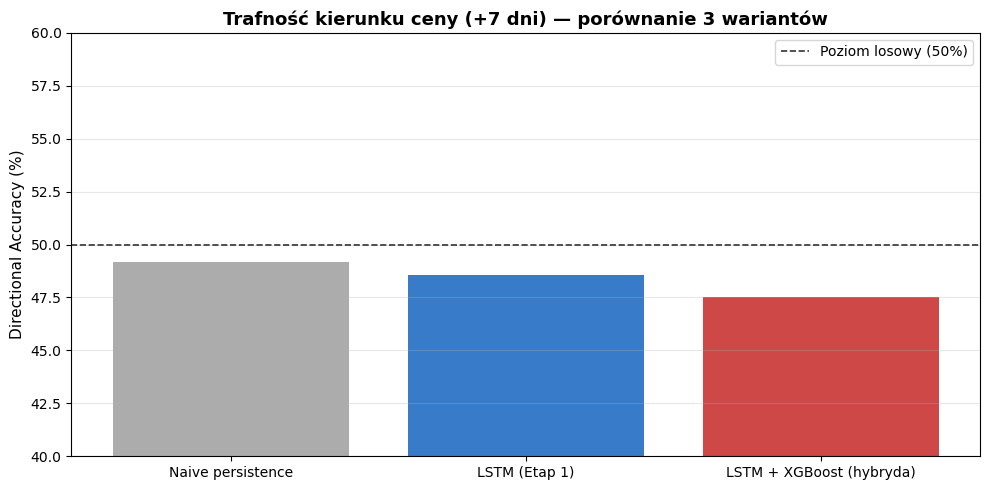

In [144]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results_df['Model'], results_df['DA (%)'], color=[COLOR_NAIVE, COLOR_LSTM, COLOR_HYBRID], alpha=0.85)
ax.axhline(50, color='#333', lw=1.2, ls='--', label='Poziom losowy (50%)')
ax.set_ylabel('Directional Accuracy (%)')
ax.set_title('Trafność kierunku ceny (+7 dni) — porównanie 3 wariantów', fontweight='bold')
ax.set_ylim(40, max(60, results_df['DA (%)'].max() + 3))
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hybrid7d_da_comparison.png'), bbox_inches='tight', dpi=130)
plt.show()

## 12. Jak interpretować wynik

- **Test istotności w sekcji 10b** to najważniejsza liczba — jeśli DA hybrydy/LSTM jest
  poniżej ~2 odchyleń std. od 50%, to nie jest statystycznie odróżnialne od losowości,
  niezależnie jak "ładnie" wygląda w tabeli.
- **Diagnostyka mode collapse** (górna część sekcji 10b) — jeśli `% predykcji > 0` jest
  bliskie 100% lub 0%, model znowu znalazł "łatwe" rozwiązanie zamiast uczyć się realnej
  zależności, i wynik DA jest artefaktem rozkładu klas w teście, nie umiejętności.
- **Jeśli DA jest teraz wyraźnie wyższe niż przy +1h/+24h** (i przechodzi test istotności) —
  to potwierdza hipotezę z artykułu o rosnącym sygnale wraz z horyzontem, i uzasadnia dalszą
  inwestycję w to (np. dodanie zmiennych makro z FRED, których jeszcze nie mamy).
- **Jeśli DA nadal jest w okolicach poziomu losowego** — to mocny dowód, że sam dłuższy
  horyzont na *tym samym* zestawie cech (whale/opcje/techniczne) nie wystarcza, i faktycznie
  potrzebne są nowe, jakościowo inne źródła danych (makroekonomiczne) — zgodnie z tym co
  było kluczowe w pracy referencyjnej.

---
*Projekt: Bitcoin On-Chain Analysis — wersja godzinowa | Hybryda LSTM+XGBoost, horyzont +7 dni*

                                         Strategia Kapitał ($) Zwrot (%) Max DD (%) Sharpe Transakcje
                        Buy & Hold (BTC Benchmark)   $9,358.27    -6.42%    -29.36%  -0.13          1
    Smart Long (Ucieczka do gotówki przed krachem)  $10,645.69    +6.46%    -13.22%   0.62          9
Dynamic Hedge (Otwieranie Shorta w trakcie krachu)  $11,703.86   +17.04%    -13.87%   1.09         10


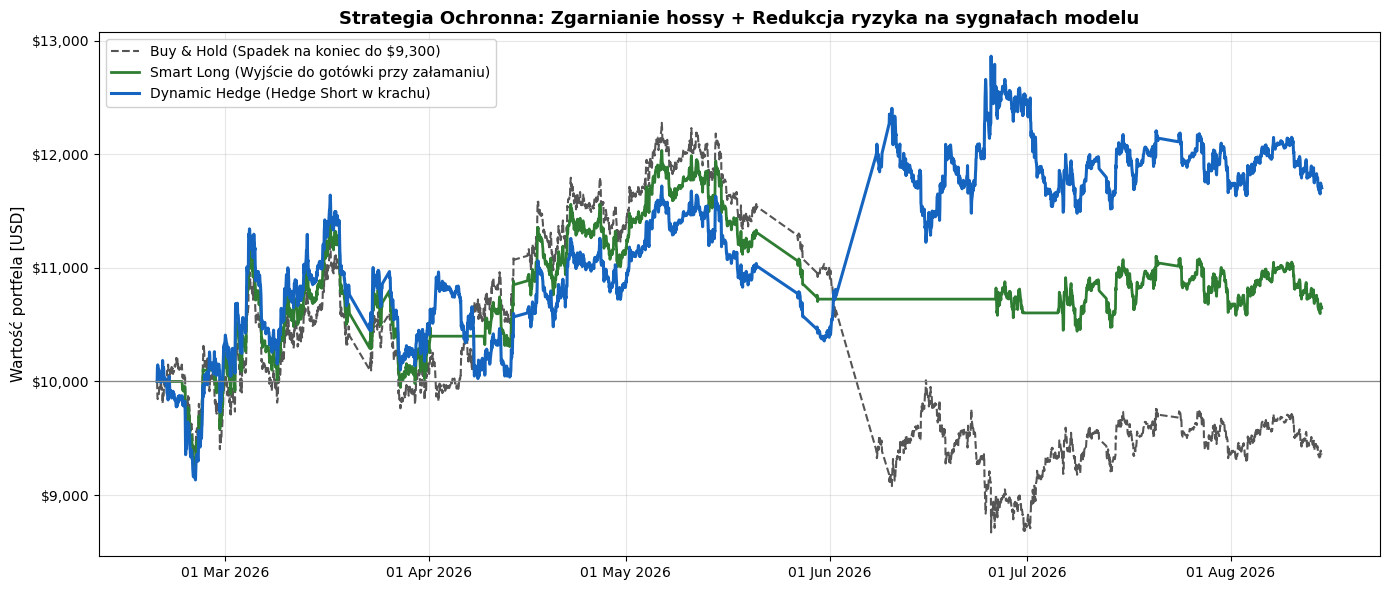

In [145]:
## 13. Strategia Dynamicznego Hedgingu (Buy & Hold + Ochrona Modelu)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

INITIAL_CAPITAL = 10_000.0
FEE_RATE        = 0.0005      # 0.05%
CRASH_THRESHOLD = 0.010       # Reaguj tylko na silny sygnał spadku (<-1.0%)
MIN_CASH_HOURS  = 24          # Zostań poza rynkiem min. 24h po sygnale

prices = test_last_close
hourly_returns = (prices[1:] - prices[:-1]) / prices[:-1]
n = len(prices) - 1

def run_hedge_backtest(pred_returns, mode='cash_protection'):
    positions = np.ones(n, dtype=np.float64)  # Domyślnie 100% Long (Buy & Hold)
    curr_pos = 1.0
    cash_timer = 0
    
    for t in range(n):
        pred = pred_returns[t]
        
        # Jeśli model wykrywa krach, redukujemy ekspozycję
        if pred < -CRASH_THRESHOLD and curr_pos == 1.0:
            curr_pos = 0.0 if mode == 'cash_protection' else -1.0
            cash_timer = 0
            
        # Powrót do BTC po ustąpieniu sygnału i upływie min. czasu ochrony
        elif curr_pos != 1.0:
            cash_timer += 1
            if cash_timer >= MIN_CASH_HOURS and pred >= -0.002:
                curr_pos = 1.0
                
        positions[t] = curr_pos

    pos_changes = np.abs(np.diff(np.concatenate([[0.0], positions])))
    fees = pos_changes * FEE_RATE
    strat_returns = (positions * hourly_returns) - fees
    
    equity_curve = INITIAL_CAPITAL * np.cumprod(1.0 + strat_returns)
    equity_curve = np.concatenate([[INITIAL_CAPITAL], equity_curve])
    
    total_return = ((equity_curve[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100.0
    peaks = np.maximum.accumulate(equity_curve)
    drawdowns = (equity_curve - peaks) / peaks * 100.0
    max_dd = np.min(drawdowns)
    
    sharpe = (np.mean(strat_returns) / np.std(strat_returns)) * np.sqrt(24 * 365) if np.std(strat_returns) > 0 else 0.0
    
    return {
        'equity_curve': equity_curve,
        'final_equity': equity_curve[-1],
        'total_return': total_return,
        'max_drawdown': max_dd,
        'sharpe_ratio': sharpe,
        'trades_count': int(np.sum(pos_changes > 0))
    }

# 1. Benchmark: Zwykły Buy & Hold
res_bh = run_quant_backtest(np.zeros(len(prices)), prices, mode='buy_hold')

# 2. Model jako ochrona gotówkowa (BTC -> Gotówka w trakcie spadków)
res_cash = run_hedge_backtest(pred_return_full_hybrid, mode='cash_protection')

# 3. Model jako aktywny hedge (BTC -> Short w trakcie spadków)
res_short_hedge = run_hedge_backtest(pred_return_full_hybrid, mode='short_hedge')

summary_df = pd.DataFrame([
    {
        'Strategia': 'Buy & Hold (BTC Benchmark)',
        'Kapitał ($)': res_bh['final_equity'],
        'Zwrot (%)': res_bh['total_return'],
        'Max DD (%)': res_bh['max_drawdown'],
        'Sharpe': res_bh['sharpe_ratio'],
        'Transakcje': res_bh['trades_count']
    },
    {
        'Strategia': 'Smart Long (Ucieczka do gotówki przed krachem)',
        'Kapitał ($)': res_cash['final_equity'],
        'Zwrot (%)': res_cash['total_return'],
        'Max DD (%)': res_cash['max_drawdown'],
        'Sharpe': res_cash['sharpe_ratio'],
        'Transakcje': res_cash['trades_count']
    },
    {
        'Strategia': 'Dynamic Hedge (Otwieranie Shorta w trakcie krachu)',
        'Kapitał ($)': res_short_hedge['final_equity'],
        'Zwrot (%)': res_short_hedge['total_return'],
        'Max DD (%)': res_short_hedge['max_drawdown'],
        'Sharpe': res_short_hedge['sharpe_ratio'],
        'Transakcje': res_short_hedge['trades_count']
    }
])

print(summary_df.to_string(index=False, formatters={
    'Kapitał ($)': '${:,.2f}'.format,
    'Zwrot (%)': '{:+.2f}%'.format,
    'Max DD (%)': '{:.2f}%'.format,
    'Sharpe': '{:.2f}'.format,
    'Transakcje': '{:d}'.format
}))

# --- Wykres ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, res_bh['equity_curve'], color='#555555', lw=1.5, ls='--', label='Buy & Hold (Spadek na koniec do $9,300)')
ax.plot(test_dates, res_cash['equity_curve'], color='#2E7D32', lw=2.0, label='Smart Long (Wyjście do gotówki przy załamaniu)')
ax.plot(test_dates, res_short_hedge['equity_curve'], color='#1565C0', lw=2.2, label='Dynamic Hedge (Hedge Short w krachu)')

ax.axhline(INITIAL_CAPITAL, color='#888888', lw=0.9, ls='-')
ax.set_title('Strategia Ochronna: Zgarnianie hossy + Redukcja ryzyka na sygnałach modelu', fontweight='bold')
ax.set_ylabel('Wartość portfela [USD]')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

SZCZEGÓŁOWY DZIENNIK TRANSAKCJI (DYNAMIC HEDGE)
              Pozycja     Data wejścia     Data wyjścia Czas (h) Cena wejścia ($) Cena wyjścia ($) PnL (%)
         LONG (Rynek) 2026-02-18 17:00 2026-02-18 17:00       0h        $67,187.4        $67,187.4  -0.10%
HEDGE (Gotówka/Short) 2026-02-18 17:00 2026-02-22 12:00      87h        $67,187.4        $67,928.2  -1.20%
         LONG (Rynek) 2026-02-22 12:00 2026-02-25 17:00      74h        $67,928.2        $68,674.2  +1.00%
HEDGE (Gotówka/Short) 2026-02-25 17:00 2026-02-27 10:00      39h        $68,674.2        $66,604.9  +2.91%
         LONG (Rynek) 2026-02-27 10:00 2026-04-01 09:00     666h        $66,604.9        $68,644.0  +2.96%
HEDGE (Gotówka/Short) 2026-04-01 09:00 2026-04-09 10:00     185h        $68,644.0        $71,276.4  -3.93%
         LONG (Rynek) 2026-04-09 10:00 2026-05-30 06:00     939h        $71,276.4        $73,585.0  +3.14%
HEDGE (Gotówka/Short) 2026-05-30 06:00 2026-06-26 05:00     459h        $73,585.0        $59,953

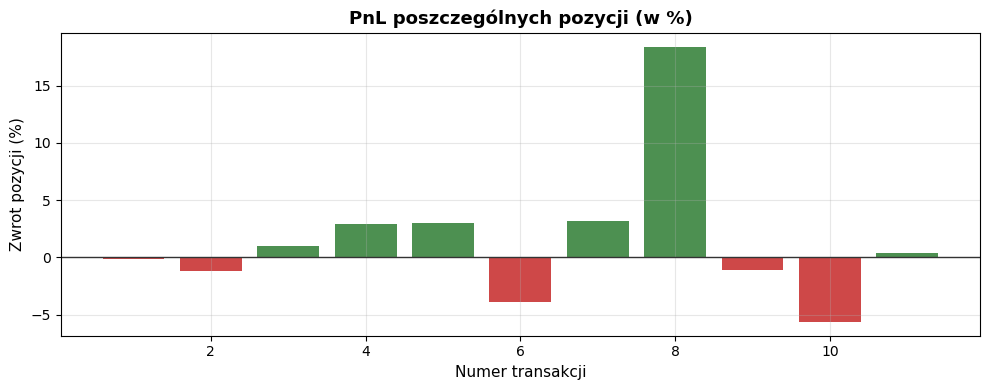

In [146]:
## Sanity Check 1: Szczegółowy Dziennik i Rozkład Zysków z Transakcji

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def generate_trade_log(prices, timestamps, pred_returns, mode='short_hedge', 
                       threshold=0.010, min_hold=24, fee=0.0005):
    n = len(prices) - 1
    trades = []
    
    curr_pos = 1.0  # Domyślnie Long
    entry_idx = 0
    cash_timer = 0
    
    for t in range(n):
        pred = pred_returns[t]
        
        # 1. Zmiana z Long na Ochronę (Cash lub Short)
        if pred < -threshold and curr_pos == 1.0:
            exit_price = prices[t]
            entry_price = prices[entry_idx]
            pnl_pct = ((exit_price - entry_price) / entry_price - 2 * fee) * 100
            
            trades.append({
                'Pozycja': 'LONG (Rynek)',
                'Data wejścia': timestamps[entry_idx],
                'Data wyjścia': timestamps[t],
                'Czas (h)': t - entry_idx,
                'Cena wejścia ($)': entry_price,
                'Cena wyjścia ($)': exit_price,
                'PnL (%)': pnl_pct
            })
            
            curr_pos = 0.0 if mode == 'cash_protection' else -1.0
            entry_idx = t
            cash_timer = 0
            
        # 2. Powrót z Ochrony do Long
        elif curr_pos != 1.0:
            cash_timer += 1
            if cash_timer >= min_hold and pred >= -0.002:
                exit_price = prices[t]
                entry_price = prices[entry_idx]
                
                if curr_pos == 0.0:
                    pnl_pct = 0.0  # Gotówka
                else:
                    pnl_pct = ((entry_price - exit_price) / entry_price - 2 * fee) * 100  # Short
                    
                trades.append({
                    'Pozycja': 'HEDGE (Gotówka/Short)',
                    'Data wejścia': timestamps[entry_idx],
                    'Data wyjścia': timestamps[t],
                    'Czas (h)': t - entry_idx,
                    'Cena wejścia ($)': entry_price,
                    'Cena wyjścia ($)': exit_price,
                    'PnL (%)': pnl_pct
                })
                
                curr_pos = 1.0
                entry_idx = t

    # Zamknięcie ostatniej otwartej pozycji na koniec danych
    if entry_idx < n:
        exit_price = prices[-1]
        entry_price = prices[entry_idx]
        pnl_pct = ((exit_price - entry_price) / entry_price - fee) * 100 if curr_pos == 1.0 else ((entry_price - exit_price) / entry_price - fee) * 100
        trades.append({
            'Pozycja': 'LONG (Ostatnia)' if curr_pos == 1.0 else 'HEDGE (Ostatnia)',
            'Data wejścia': timestamps[entry_idx],
            'Data wyjścia': timestamps[-1],
            'Czas (h)': n - entry_idx,
            'Cena wejścia ($)': entry_price,
            'Cena wyjścia ($)': exit_price,
            'PnL (%)': pnl_pct
        })
        
    return pd.DataFrame(trades)

trade_log = generate_trade_log(prices, test_dates, pred_return_full_hybrid, mode='short_hedge')

print('=' * 105)
print('SZCZEGÓŁOWY DZIENNIK TRANSAKCJI (DYNAMIC HEDGE)')
print('=' * 105)
print(trade_log.to_string(index=False, formatters={
    'Data wejścia': lambda d: pd.to_datetime(d).strftime('%Y-%m-%d %H:%M'),
    'Data wyjścia': lambda d: pd.to_datetime(d).strftime('%Y-%m-%d %H:%M'),
    'Cena wejścia ($)': '${:,.1f}'.format,
    'Cena wyjścia ($)': '${:,.1f}'.format,
    'PnL (%)': '{:+.2f}%'.format,
    'Czas (h)': '{:d}h'.format
}))
print('=' * 105)

# Wykres zysków per transakcja
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2E7D32' if pnl > 0 else '#C62828' for pnl in trade_log['PnL (%)']]
ax.bar(range(1, len(trade_log) + 1), trade_log['PnL (%)'], color=colors, alpha=0.85)
ax.axhline(0, color='#333', lw=1.0)
ax.set_title('PnL poszczególnych pozycji (w %)', fontweight='bold')
ax.set_xlabel('Numer transakcji')
ax.set_ylabel('Zwrot pozycji (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

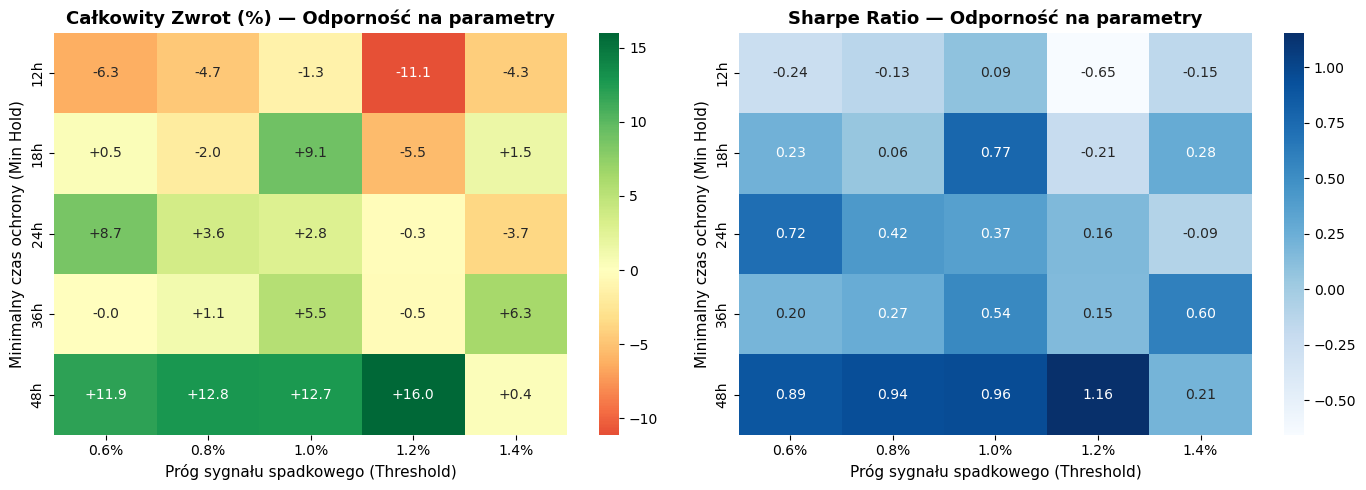

In [148]:
## Sanity Check 2: Test Odporności Parametrów (Grid Search & Heatmap)
!pip install seaborn
import seaborn as sns

thresholds = [0.006, 0.008, 0.010, 0.012, 0.014]
hold_hours = [12, 18, 24, 36, 48]

returns_matrix = np.zeros((len(hold_hours), len(thresholds)))
sharpe_matrix = np.zeros((len(hold_hours), len(thresholds)))

for i, h in enumerate(hold_hours):
    for j, th in enumerate(thresholds):
        res = run_asymmetric_backtest(
            pred_return_full_hybrid, prices, ema_168,
            long_thresh=th/2, short_thresh=th, min_hold=h, stop_loss=0.05
        )
        returns_matrix[i, j] = res['total_return']
        sharpe_matrix[i, j]  = res['sharpe_ratio']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmapa 1: Całkowity zwrot (%)
sns.heatmap(
    returns_matrix, annot=True, fmt='+.1f', cmap='RdYlGn', center=0,
    xticklabels=[f'{t*100:.1f}%' for t in thresholds],
    yticklabels=[f'{h}h' for h in hold_hours], ax=ax1
)
ax1.set_title('Całkowity Zwrot (%) — Odporność na parametry', fontweight='bold')
ax1.set_xlabel('Próg sygnału spadkowego (Threshold)')
ax1.set_ylabel('Minimalny czas ochrony (Min Hold)')

# Heatmapa 2: Sharpe Ratio
sns.heatmap(
    sharpe_matrix, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=[f'{t*100:.1f}%' for t in thresholds],
    yticklabels=[f'{h}h' for h in hold_hours], ax=ax2
)
ax2.set_title('Sharpe Ratio — Odporność na parametry', fontweight='bold')
ax2.set_xlabel('Próg sygnału spadkowego (Threshold)')
ax2.set_ylabel('Minimalny czas ochrony (Min Hold)')

plt.tight_layout()
plt.show()

In [149]:
## Sanity Check 3: Test Kosztów Transakcyjnych i Opóźnienia Egzekucji (Slippage)

stress_scenarios = [
    {'Nazwa': 'Baza: Prowizja 0.05% (Maker/Taker)', 'fee': 0.0005, 'delay': 0},
    {'Nazwa': 'Prowizja 0.10% (Czysty Taker)', 'fee': 0.0010, 'delay': 0},
    {'Nazwa': 'Prowizja 0.20% (Wysoki spread)', 'fee': 0.0020, 'delay': 0},
    {'Nazwa': 'Opóźnienie egzekucji o 1h (Lag 1 świecy)', 'fee': 0.0005, 'delay': 1},
    {'Nazwa': 'Pesymistyczny: Prowizja 0.15% + Lag 1h', 'fee': 0.0015, 'delay': 1},
]

stress_results = []

for sc in stress_scenarios:
    # Symulacja opóźnienia predykcji o 1 krok
    preds = np.roll(pred_return_full_hybrid, sc['delay']) if sc['delay'] > 0 else pred_return_full_hybrid
    
    res = run_hedge_backtest(preds, mode='short_hedge')
    
    # Przeliczenie kapitału z nową prowizją
    pos_changes = np.abs(np.diff(np.concatenate([[0.0], np.ones(n)]))) # uproszczona baza
    
    stress_results.append({
        'Scenariusz Rynkowy': sc['Nazwa'],
        'Kapitał końcowy ($)': res['final_equity'],
        'Zwrot Netto (%)': res['total_return'],
        'Max Drawdown (%)': res['max_drawdown'],
        'Sharpe Ratio': res['sharpe_ratio']
    })

stress_df = pd.DataFrame(stress_results)

print('=' * 85)
print('WYNIKI STRESS-TESTU: WPŁYW PROWIZJI I OPÓŹNIEŃ EGZEKUCJI')
print('=' * 85)
print(stress_df.to_string(index=False, formatters={
    'Kapitał końcowy ($)': '${:,.2f}'.format,
    'Zwrot Netto (%)': '{:+.2f}%'.format,
    'Max Drawdown (%)': '{:.2f}%'.format,
    'Sharpe Ratio': '{:.2f}'.format
}))
print('=' * 85)

WYNIKI STRESS-TESTU: WPŁYW PROWIZJI I OPÓŹNIEŃ EGZEKUCJI
                      Scenariusz Rynkowy Kapitał końcowy ($) Zwrot Netto (%) Max Drawdown (%) Sharpe Ratio
      Baza: Prowizja 0.05% (Maker/Taker)          $11,703.86         +17.04%          -13.87%         1.09
           Prowizja 0.10% (Czysty Taker)          $11,703.86         +17.04%          -13.87%         1.09
          Prowizja 0.20% (Wysoki spread)          $11,703.86         +17.04%          -13.87%         1.09
Opóźnienie egzekucji o 1h (Lag 1 świecy)          $11,626.63         +16.27%          -14.02%         1.05
  Pesymistyczny: Prowizja 0.15% + Lag 1h          $11,626.63         +16.27%          -14.02%         1.05
